In [13]:
# вычисление и визуализация
# численного решения нестационарного
# уравнения Шредингера

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt


In [14]:
# Ячейка № 2

# задание функции, реализующей
# вычислительный алгоритм
# вариационного метода
# вычисления энергии
# основного состояния
# гармонического осциллятора
def Variation(x, Delta, N_Move):
    # x - массив, содержащий координаты
    #     узлов, выбранной сетки
    # Delta - максимальная вариация
    #         "мгновенной" волновой функции
    # N_Move - число итераций

    # задание функции, возвращающей
    # значения начального приближения
    # волновой функции
    def F(x):
        # x - массив, содержащий
        #     значения координат узлов
        #     используемой сетки
        return np.exp(-(x**2))

    # задание функции, возвращающей
    # значения потенциала
    def V(x):
        # x - массив, содержащий
        #     значения координат узлов
        #     используемой сетки
        return 0.5 * x**2

    # задание функции, возвращающей
    # "мгновенное" значение
    # потенциальной энергии,
    # соответствующее "мгновенной"
    # волновой функции
    def E_Potential(x, Psi):
        # x - массив, содержащий
        #     значения координат узлов
        #     используемой сетки
        # Psi - массив, содержащий значения
        #       "мгновенной" волновой функции
        return np.trapz(Psi**2 * V(x), x)

    # задание функции, возвращающей
    # "мгновенное" значение
    # кинетической энергии,
    # соответствующее "мгновенной"
    # волновой функции
    def E_Kinetic(x, Psi):
        # x - массив, содержащий
        #     значения координат узлов
        #     используемой сетки
        # Psi - массив, содержащий значения
        #       "мгновенной" волновой функции
        Dx = x[1] - x[0]
        K = np.zeros(len(x))
        for i in range(1, len(x) - 1):
            K[i - 1] = 0.5 * Psi[i] * (2 * Psi[i] - Psi[i + 1] - Psi[i - 1]) / Dx**2
        return np.trapz(K, x)

    # задание функции, возвращающей
    # значения номированной
    # волновой функции
    def Psi_Normalization(x, Psi):
        # x - массив, содержащий
        #     значения координат узлов
        #     используемой сетки
        # Psi - массив, содержащий значения
        #       "мгновенной" волновой функции
        Norm = np.trapz(Psi**2, x)
        return Psi / np.sqrt(Norm)

    # определение числа узлов
    # выбранной сетки
    N_Grid = len(x)

    # вычисление значения ненормированной
    # начальной волновой функции
    Psi = F(x)

    # вычисление значений
    # нормированной волновой функции
    Psi_Norm = Psi_Normalization(x, Psi)

    # вычисление начального значения
    # кинетической энергии
    # квантового гармонического осциллятора
    E_P = E_Potential(x, Psi_Norm)

    # вычисление начального значения
    # потенциальной энергии
    # квантового гармонического осциллятора
    E_K = E_Kinetic(x, Psi_Norm)

    # вычисление начального значения
    # полной энергии
    # квантового гармонического осциллятора
    E_Full = E_P + E_K

    # инициализация массива, используемого
    # хранения принятых значений энергии
    E = np.array([E_Full])

    # инициализация массива, используемого
    # хранения значений начальной
    # нормированной волновой функции
    Psi_Step_Norm = np.zeros(N_Grid)

    # размещение в массиве Psi_Step_Norm
    # нормированных значений функции, выбранной в
    # качестве начального приближения
    Psi_Step_Norm[:] = Psi_Norm[:]

    # инициализация массива, используемого
    # хранения значений начальной
    # волновой функции, вычисленных на
    # предыдущем шаге итерационного процесса
    Psi_Trial_Norm_Old = np.zeros(N_Grid)

    # размещение в массиве Psi_Step_Norm
    # нормированных значений функции, выбранной в
    # качестве начального приближения
    Psi_Trial_Norm_Old[:] = Psi_Step_Norm[:]

    # инициализация счетчика числа
    # принятых вариаций
    # "мгновенных" волновых функций
    k = 0

    # инициализация массива, используемого
    # хранения варьированных значений
    # волновой функции, вычисленных на
    # данном шаге итерационного процесса
    Psi_Trial_New = np.zeros(N_Grid)

    # инициализация массива, используемого
    # хранения нормированных варьированных значений
    # волновой функции, вычисленных на
    # данном шаге итерационного процесса
    Psi_Trial_New_Norm = np.zeros(N_Grid)

    # реализация итерационного процесса
    for i in range(1, N_Move):
        # случайный выбор номера варьируемой точки
        I_Move = np.random.randint(0, (N_Grid - 1) / 2)

        # случайный выбор значения вариации
        # "мгновенной" волновой функции
        d_Psi = np.random.uniform(-Delta / 2, Delta / 2)

        # если значение I_Move не равняется (N_Grid-1) / 2,
        # изменяем значения "мгновенной" волновой функции на d_Psi
        # с номерами I_Move и N_Grid - I_Move - 1
        if I_Move < ((N_Grid - 1) / 2):
            # перемещение значений "мгновенной"
            # нормированной волновой функции,
            # вычисленных на предыдущем итерационном шаге
            # из массива Psi_Trial_Norm_Old в
            # массив  Psi_Trial_New
            Psi_Trial_New[:] = Psi_Trial_Norm_Old[:]

            # варьирование значений нормированной волновой функции,
            # вычисленных на предыдущем интерационном шаге
            Psi_Trial_New[I_Move] = Psi_Trial_Norm_Old[I_Move] + d_Psi
            Psi_Trial_New[N_Grid - I_Move - 1] = Psi_Trial_New[I_Move]

        # если значение I_Move не равняется (N_Grid-1) / 2,
        # изменяем значения "мгновенной" волновой функции на 2 * d_Psi
        else:
            Psi_Trial_New[I_Move] = Psi_Trial_Norm_Old[I_Move] + 2 * d_Psi

        # нормируем варьированные значения волновой функции
        Psi_Trial_New_Norm = Psi_Normalization(x, Psi_Trial_New)

        # вычисляем полную энергию
        # квантового гармонического осциллятора,
        # соответствующую варьированному значеию волновой функции
        E_Full_Trial = E_Kinetic(x, Psi_Trial_New_Norm) + E_Potential(
            x, Psi_Trial_New_Norm
        )

        # если полная энергия квантового
        # гармонического осциллятора уменьшилась,
        # сохранение результатов вариации волновой функции
        if E_Full_Trial - E[k] < 0:
            # добавление значения энергии,
            # соответствующего проварьированной
            # волновой функции в массив E
            E = np.hstack((E, E_Full_Trial))

            # добавление проварьированной нормированной
            # волновой функции в массив Psi_Step_Norm
            Psi_Step_Norm = np.vstack((Psi_Step_Norm, Psi_Trial_New_Norm))
            k = k + 1
            Psi_Trial_Norm_Old[:] = Psi_Trial_New_Norm[:]

    return E, Psi_Step_Norm

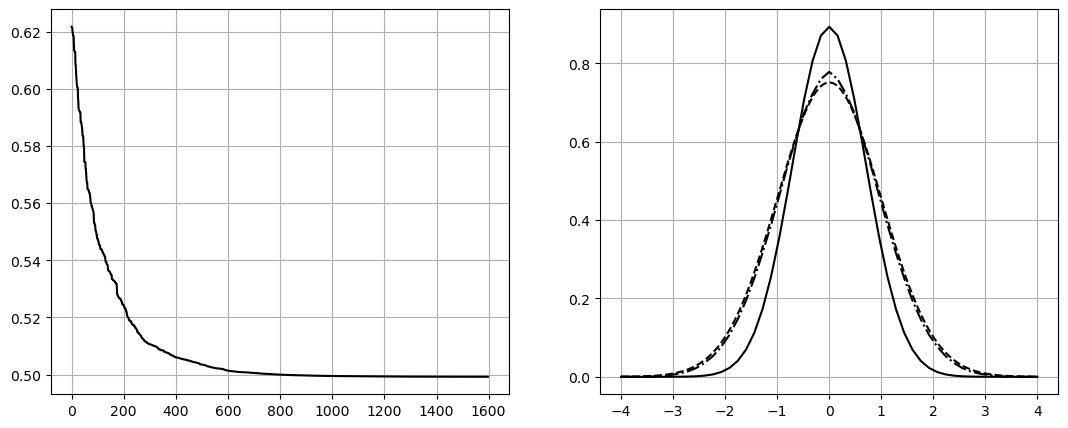

In [ ]:
# Ячейка № 3

# инициализация генератора случайных чисел
np.random.seed()

# вычисление энергии
# основного состояния
# квантового гармонического осциллятора
# вариационным методом

# задание минимального
# значения координаты
X_min = -4

# задание максимального
# значения координаты
X_max = -X_min

# задание нечетного
# числа узлов
# координатной сетки
N_Grid = 51

# задание максимального значения
# вариации волновой функции
Delta = 0.1

# задание числа шагов итерационного процесса
N_Move = 10**4 * N_Grid

# задание координат узлов сетки
x = np.linspace(X_min, X_max, N_Grid)

# вычисление "мгновенных" значений
# энергии основного состояния
# гармонического осциллятора и
# соответствующих волновых функций
[E_Variable, Psi_Variable] = Variation(x, Delta, N_Move)

# вычисление значений
# точного решения
# уравнения Шредингера
# гармонического осциллятора

# задание координат узлов сетки
x2 = np.linspace(X_min, X_max, 10**3)

# вычисление значений ненормированной
# волновой функции основного состояния
# гармонического осциллятора
Psi_theory = np.exp(-(x2**2) / 2)

# вычисление нормировочного коэффициента
Coeff = np.trapz(Psi_theory**2, x2)

# визуализация результатов расчетов
fig = plt.figure(figsize=(13, 11))

# визуализация зависимости
# энергии основного состояния
# гармонического осциллятора
# от номера шага итерации
ax = plt.subplot(2, 2, 1)
plt.plot(E_Variable, "-k")
plt.grid(True)

# визуализация начальной волновой функций,
# волновой функции на выбранной итерации,
# точного решения уравнения Шредингера
# гармонического осциллятора
ax = plt.subplot(2, 2, 2)

# визуализация начального решения
plt.plot(x, Psi_Variable[0, :], "-k")

# визуализация решения на 600-м шаге итераций
plt.plot(x, Psi_Variable[600, :], "-.k")

# визуализация значений
# нормированной волновой функции
# основного состояния
# квантового гармонического осциллятора,
# вычисленных на основе аналитического решения
plt.plot(x2, Psi_theory / np.sqrt(Coeff), "--k")
plt.grid(True)

plt.show()